# Homework 3

## Problem 1

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn import datasets
from sklearn import linear_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from itertools import combinations

In [30]:
diabetes = datasets.load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [31]:
df["target"] = diabetes.target
df = df[["age", "bmi", "bp", "s4", "s5", "s6", "target"]]

x = df[["age", "bmi", "bp", "s4", "s5", "s6"]]
y = df["target"]

train, test = train_test_split(df, test_size=0.1, random_state=0)
x_train = train.iloc[:, :-1]
y_train = train["target"]
x_test = test.iloc[:, :-1]
y_test = test["target"]


def AIC(train_data, train_label):
    lm = linear_model.LinearRegression().fit(train_data, train_label)
    predict_label = lm.predict(train_data)
    degree_freedom = train_data.shape[1]
    sample_size = train_data.shape[0]
    SSE = np.dot((train_label - predict_label), (train_label - predict_label))
    return sample_size * np.log(SSE / sample_size) + 2 * degree_freedom


def BIC(train_data, train_label):
    lm = linear_model.LinearRegression().fit(train_data, train_label)
    predict_label = lm.predict(train_data)
    degree_freedom = train_data.shape[1]
    sample_size = train_data.shape[0]
    SSE = np.dot((train_label - predict_label), (train_label - predict_label))
    return (
        sample_size * np.log(SSE / sample_size) + np.log(sample_size) * degree_freedom
    )

### Part 1

[('age',), ('bmi',), ('bp',), ('s4',), ('s5',), ('s6',)]
[3445.0702831782537, 3283.605308765753, 3367.2152414322304, 3372.872002795993, 3295.766495779789, 3393.075676892412]
[('age', 'bmi'), ('age', 'bp'), ('age', 's4'), ('age', 's5'), ('age', 's6'), ('bmi', 'bp'), ('bmi', 's4'), ('bmi', 's5'), ('bmi', 's6'), ('bp', 's4'), ('bp', 's5'), ('bp', 's6'), ('s4', 's5'), ('s4', 's6'), ('s5', 's6')]
[3282.7064010476374, 3368.87519085324, 3370.896989593179, 3297.421361521931, 3393.0756059947644, 3250.990802992623, 3257.402097658966, 3202.9933762738447, 3266.900061205004, 3311.1640289705133, 3263.619187661592, 3341.023301399027, 3291.6917399319886, 3350.5593967608033, 3287.803769451938]
[('age', 'bmi', 'bp'), ('age', 'bmi', 's4'), ('age', 'bmi', 's5'), ('age', 'bmi', 's6'), ('age', 'bp', 's4'), ('age', 'bp', 's5'), ('age', 'bp', 's6'), ('age', 's4', 's5'), ('age', 's4', 's6'), ('age', 's5', 's6'), ('bmi', 'bp', 's4'), ('bmi', 'bp', 's5'), ('bmi', 'bp', 's6'), ('bmi', 's4', 's5'), ('bmi', 's4', '

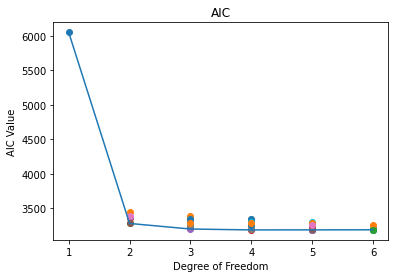

The minimum AIC values are:  [6049.931277510621, 3283.605308765753, 3202.9933762738447, 3190.0291671413993, 3190.6810335601804, 3191.727249611546]
Minimum AIC value is:  3190.0291671413993
The corresponding variables are: bmi, bp, s5


In [32]:
feature_names = list(x_train.columns.values)
min_AIC = []
min_AIC.append(y_train.var())
plt.scatter(1, y_train.var())  # when there is only the intercept term, plot variance
for i in range(1, 6):
    names = list(
        combinations(feature_names, i)
    )  # generate the combination of i feature names and convert it to a list
    print(names)
    aic_list = []  # define a list to store AIC values
    for each_element in names:
        aic_list.append(
            AIC(x_train[list(each_element)], y_train)
        )  # append BIC values to the list
    min_AIC.append(np.min(aic_list))
    print(aic_list)
    for each_value in aic_list:
        plt.scatter(x=i + 1, y=each_value)  # plot AIC values

plt.plot([1, 2, 3, 4, 5, 6], min_AIC)
plt.title("AIC")
plt.xlabel("Degree of Freedom")
plt.ylabel("AIC Value")
plt.show()

print("The minimum AIC values are: ", min_AIC)
print("Minimum AIC value is: ", np.min(min_AIC))
print("The corresponding variables are: bmi, bp, s5")

### Part 2

[('age',), ('bmi',), ('bp',), ('s4',), ('s5',), ('s6',)]
[3449.0542194589407, 3287.58924504644, 3371.1991777129174, 3376.85593907668, 3299.7504320604758, 3397.059613173099]
[('age', 'bmi'), ('age', 'bp'), ('age', 's4'), ('age', 's5'), ('age', 's6'), ('bmi', 'bp'), ('bmi', 's4'), ('bmi', 's5'), ('bmi', 's6'), ('bp', 's4'), ('bp', 's5'), ('bp', 's6'), ('s4', 's5'), ('s4', 's6'), ('s5', 's6')]
[3290.674273609012, 3376.8430634146143, 3378.8648621545535, 3305.3892340833054, 3401.043478556139, 3258.958675553997, 3265.3699702203403, 3210.961248835219, 3274.8679337663784, 3319.1319015318877, 3271.5870602229666, 3348.9911739604013, 3299.659612493363, 3358.5272693221777, 3295.7716420133124]
[('age', 'bmi', 'bp'), ('age', 'bmi', 's4'), ('age', 'bmi', 's5'), ('age', 'bmi', 's6'), ('age', 'bp', 's4'), ('age', 'bp', 's5'), ('age', 'bp', 's6'), ('age', 's4', 's5'), ('age', 's4', 's6'), ('age', 's5', 's6'), ('bmi', 'bp', 's4'), ('bmi', 'bp', 's5'), ('bmi', 'bp', 's6'), ('bmi', 's4', 's5'), ('bmi', 's4

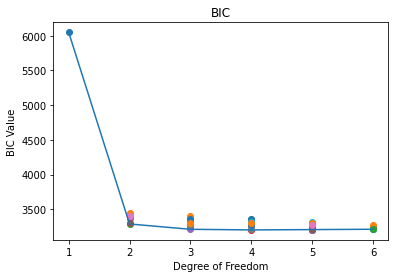

The minimum BIC values are:  [6049.931277510621, 3287.58924504644, 3210.961248835219, 3201.9809759834607, 3206.616778682929, 3211.646931014982]
Minimum BIC value is:  3201.9809759834607
The corresponding variables are: bmi, bp, s5


In [33]:
feature_names = list(x_train.columns.values)
min_BIC = []
min_BIC.append(y_train.var())
plt.scatter(1, y_train.var())  # when there is only the intercept term, plot variance
for i in range(1, 6):
    names = list(
        combinations(feature_names, i)
    )  # generate the combination of i feature names and convert it to a list
    print(names)
    bic_list = []  # define a list to store BIC values
    for each_element in names:
        bic_list.append(
            BIC(x_train[list(each_element)], y_train)
        )  # append BIC values to the list
    print(bic_list)
    min_BIC.append(np.min(bic_list))
    for each_value in bic_list:
        plt.scatter(x=i + 1, y=each_value)  # plot BIC values
plt.plot([1, 2, 3, 4, 5, 6], min_BIC)
plt.title("BIC")
plt.xlabel("Degree of Freedom")
plt.ylabel("BIC Value")
plt.show()

print("The minimum BIC values are: ", min_BIC)
print("Minimum BIC value is: ", np.min(min_BIC))
print("The corresponding variables are: bmi, bp, s5")

### Part 3
a. Yes, both AIC & BIC select the 4th model for the minimum associated value. 

b. Use BIC for larger datasets

## Problem 2

In [34]:
data = pd.read_csv("prostate_HW3.csv")
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   lcavol   97 non-null     float64
 1   lweight  97 non-null     float64
 2   age      97 non-null     int64  
 3   lbph     97 non-null     float64
 4   svi      97 non-null     int64  
 5   lcp      97 non-null     float64
 6   gleason  97 non-null     int64  
 7   pgg45    97 non-null     int64  
 8   lpsa     97 non-null     float64
 9   train    97 non-null     object 
dtypes: float64(5), int64(4), object(1)
memory usage: 7.7+ KB


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,1.350010,3.628943,63.865979,0.100356,0.216495,-0.179366,6.752577,24.381443,2.478387
std,1.178625,0.428411,7.445117,1.450807,0.413995,1.398250,0.722134,28.204035,1.154329
min,-1.347074,2.374906,41.000000,-1.386294,0.000000,-1.386294,6.000000,0.000000,-0.430783
25%,0.512824,3.375880,60.000000,-1.386294,0.000000,-1.386294,6.000000,0.000000,1.731656
50%,1.446919,3.623007,65.000000,0.300105,0.000000,-0.798508,7.000000,15.000000,2.591516
75%,2.127041,3.876396,68.000000,1.558145,0.000000,1.178655,7.000000,40.000000,3.056357
max,3.821004,4.780383,79.000000,2.326302,1.000000,2.904165,9.000000,100.000000,5.582932


In [ ]:
x = data[["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]]
y = data["lpsa"]

train = data[data["train"] == "T"]
test = data[data["train"] == "F"]

x_train = train[["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]]
y_train = train["lpsa"]

x_test = test[["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]]
y_test = test["lpsa"]

model = linear_model.LassoCV(cv=5).fit(x_train, y_train)

y_pred = model.predict(x_test)
test_mse = mean_squared_error(y_test, y_pred)

print(f"Best Lambda (α): {model.alpha_}")
print("\nEstimated Regression Coefficients:")
print(pd.Series(model.coef_, index=x_train.columns))
print(f"\nTest Error (MSE): {test_mse:.4f}")

Best Lambda (α): 0.015620205250278461

Estimated Regression Coefficients:
lcavol     0.563407
lweight    0.555160
age       -0.017268
lbph       0.140948
svi        0.562291
lcp       -0.146627
gleason   -0.000000
pgg45      0.008434
dtype: float64

Test Error (MSE): 0.5052
LassoCV(cv=5)


## Problem 3